<a href="https://colab.research.google.com/github/Psyche-1/goit-ds-hw/blob/main/Hw3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [49]:
import matplotlib.pyplot as plt

In [3]:
from sklearn.linear_model import LinearRegression

In [94]:
from sklearn.metrics import r2_score

In [4]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Housing.csv'

df = pd.read_csv(file_path)
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
df.duplicated().sum()

np.int64(0)

напишіть функцію гіпотези лінійної регресії у векторному вигляді;

In [8]:
def h(X, w):
  return np.dot(X, w)

створіть функцію для обчислення функції втрат у векторному вигляді;

In [97]:
def calc_loss(X, y, w):
  m = len(y)
  return (1 / (2 * m)) * np.sum(np.square(h(X, w) - y))

реалізуйте один крок градієнтного спуску;

In [98]:
def gradient_step(X, y, w, alpha):
  m = len(y)
  gradient = (1 / m) * (X.T @ (h(X, w) - y))
  w = w - alpha * gradient
  return w

In [99]:
def gradient_descent(X, y, w, alpha, iterations):
  loss_history = []
  for i in range(iterations):
      w = gradient_step(X, y, w, alpha)

      loss = calc_loss(X, y, w)
      loss_history.append(loss)

  return w, loss_history

знайдіть найкращі параметри w для датасету використовуючи написані вами функції, прогнозуючу ціну на будинок залежно від площі, кількості ванних кімнат та кількості спалень;

In [100]:
X = df[['area', 'bedrooms', 'bathrooms']].values
y = df['price'].values.reshape(-1, 1)

mu_X, sigma_X = np.mean(X, axis=0), np.std(X, axis=0)
mu_y, sigma_y = np.mean(y), np.std(y)

X_norm = (X - mu_X) / sigma_X
y_norm = (y - mu_y) / sigma_y

X_norm = np.hstack([np.ones((len(y), 1)), X_norm])

w = np.zeros((X_norm.shape[1], 1))
alpha = 1
iterations = 50

w_final, loss_history = gradient_descent(X_norm, y_norm, w, alpha, iterations)

In [101]:
w_final.round(10)

array([[0.        ],
       [0.43945209],
       [0.16052866],
       [0.37234442]])

знайдіть ці ж параметри за допомогою аналітичного рішення;

In [44]:
def normal_equation(X, y):
   theta = np.linalg.inv(X.T @ X) @ X.T @ y
   return theta.round(10)

In [45]:
normal_equation(X_norm, y_norm)

array([[0.        ],
       [0.43945209],
       [0.16052866],
       [0.37234442]])

для перевірки спрогнозованих значень, використайте LinearRegression з бібліотеки scikit-learn та порівняйте результати.

In [105]:
model = LinearRegression()
model.fit(X_norm[:, 1:], y_norm)
intercept = model.intercept_.round(10)
coefficients = model.coef_.round(10)

In [106]:
intercept

array([0.])

In [107]:
coefficients

array([[0.43945209, 0.16052866, 0.37234442]])

Порівняння результатів: усіма трьома методами отримані значення коефіцієнтів співпали, як мінімум на 10 знаків. Збільшуючи alpha вдалося значно зменшити iterations при збереженні коефіцієнтів.

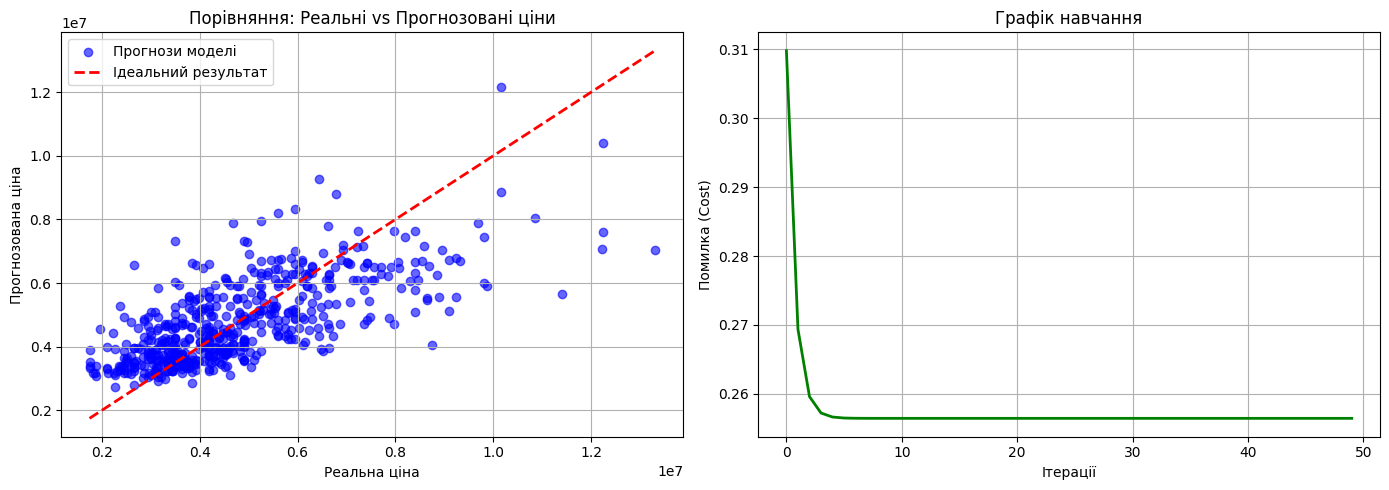

In [93]:
y_pred_manual = X_norm @ w_final
y_real_scaled = y
y_pred_real = y_pred_manual * np.std(y) + np.mean(y)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_real_scaled, y_pred_real, color='blue', alpha=0.6, label='Прогнози моделі')
plt.plot([y_real_scaled.min(), y_real_scaled.max()],
         [y_real_scaled.min(), y_real_scaled.max()],
         'r--', lw=2, label='Ідеальний результат')

plt.xlabel('Реальна ціна')
plt.ylabel('Прогнозована ціна')
plt.title('Порівняння: Реальні vs Прогнозовані ціни')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(loss_history, color='green', lw=2)
plt.xlabel('Ітерації')
plt.ylabel('Помилка (Cost)')
plt.title('Графік навчання')
plt.grid(True)

plt.tight_layout()
plt.show()

In [95]:
r2_score(y_real_scaled, y_pred_real)

0.4870830667058762